# ¿Se puede entrenar un modelo que prediga correctamente alguna enfermedad pulmonar presente en una radiografía a partir de la imagen?

Para responderla se entrenaron 14 modelos DenseNet-121 (uno por enfermedad) con resolución 128×128 y 1 época, usando Weighted BCE Loss para compensar el desbalance de clases. Cada modelo aprende a detectar una sola patología de forma binaria.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / '.git').exists():
            return p
    return start
root = find_root()
os.chdir(root)

results = [
    ('Effusion',          0.813, 12722, 7222, 383, 2071, 0.353),
    ('Edema',             0.807, 14393, 7578,  64,  363, 0.087),
    ('Atelectasis',       0.710, 12549, 7644, 693, 1512, 0.266),
    ('Consolidation',     0.671, 16472, 4980, 536,  410, 0.129),
    ('Cardiomegaly',      0.649,  3829, 18010, 30,  529, 0.055),
    ('Fibrosis',          0.644,  9123, 12921, 69,  285, 0.042),
    ('Pneumonia',         0.635, 16708, 5413, 165,  112, 0.039),
    ('Pneumothorax',      0.609, 10440, 10813,409,  736, 0.116),
    ('Infiltration',      0.598,  8482, 10071,1227, 2618, 0.317),
    ('Hernia',            0.585, 18466, 3904,  22,    6, 0.003),
    ('Pleural Thickening',0.565, 20597, 1046, 717,   38, 0.041),
    ('Nodule',            0.529,     0, 21086,  0,  1312, 0.111),
    ('Emphysema',         0.525, 20827, 1008, 524,   39, 0.048),
    ('Mass',              0.522, 21285,    0, 1113,   0, 0.000),
]

df = pd.DataFrame(results, columns=['Enfermedad', 'AUC', 'TN', 'FP', 'FN', 'TP', 'F1'])
df['Prevalencia'] = (df['TP'] + df['FN']) / (df['TN'] + df['FP'] + df['FN'] + df['TP'])
df = df.sort_values('AUC', ascending=False).reset_index(drop=True)
df.index += 1
df

,Enfermedad,AUC,TN,FP,FN,TP,F1,Prevalencia
1,Effusion,0.813,12722,7222,383,2071,0.353,0.109563
2,Edema,0.807,14393,7578,64,363,0.087,0.019064
3,Atelectasis,0.710,12549,7644,693,1512,0.266,0.098446
4,Consolidation,0.671,16472,4980,536,410,0.129,0.042236
5,Cardiomegaly,0.649,3829,18010,30,529,0.055,0.024958
6,Fibrosis,0.644,9123,12921,69,285,0.042,0.015805
7,Pneumonia,0.635,16708,5413,165,112,0.039,0.012367
8,Pneumothorax,0.609,10440,10813,409,736,0.116,0.051121
9,Infiltration,0.598,8482,10071,1227,2618,0.317,0.171667
10,Hernia,0.585,18466,3904,22,6,0.003,0.001250


In [7]:
print(df.to_markdown(index=True))

|    | Enfermedad         |   AUC |    TN |    FP |   FN |   TP |    F1 |   Prevalencia |
|---:|:-------------------|------:|------:|------:|-----:|-----:|------:|--------------:|
|  1 | Effusion           | 0.813 | 12722 |  7222 |  383 | 2071 | 0.353 |    0.109563   |
|  2 | Edema              | 0.807 | 14393 |  7578 |   64 |  363 | 0.087 |    0.0190642  |
|  3 | Atelectasis        | 0.71  | 12549 |  7644 |  693 | 1512 | 0.266 |    0.0984463  |
|  4 | Consolidation      | 0.671 | 16472 |  4980 |  536 |  410 | 0.129 |    0.0422359  |
|  5 | Cardiomegaly       | 0.649 |  3829 | 18010 |   30 |  529 | 0.055 |    0.0249576  |
|  6 | Fibrosis           | 0.644 |  9123 | 12921 |   69 |  285 | 0.042 |    0.015805   |
|  7 | Pneumonia          | 0.635 | 16708 |  5413 |  165 |  112 | 0.039 |    0.0123672  |
|  8 | Pneumothorax       | 0.609 | 10440 | 10813 |  409 |  736 | 0.116 |    0.0511206  |
|  9 | Infiltration       | 0.598 |  8482 | 10071 | 1227 | 2618 | 0.317 |    0.171667   |
| 10 | Her

La tabla anterior resume las métricas obtenidas para cada enfermedad. El AUC mide la capacidad del modelo para separar enfermos de sanos, mientras que el F1-Score combina precisión y sensibilidad en una sola métrica. La prevalencia indica qué tan frecuente es cada enfermedad en el conjunto de test. Se observa una gran disparidad: Effusion y Edema superan AUC de 0.80, mientras que Mass, Emphysema y Nodule apenas superan 0.52, muy cerca del azar. Esta variación sugiere que algunas enfermedades tienen patrones radiológicos más distintivos que otras, incluso con resolución limitada.

## Curva ROC Comparativa

La curva ROC muestra la relación entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (1 - especificidad) para distintos umbrales de clasificación. Una curva más cercana a la esquina superior izquierda indica mejor rendimiento. La línea diagonal punteada representa un clasificador aleatorio (AUC=0.50). En esta figura se superponen las 14 curvas, una por enfermedad.

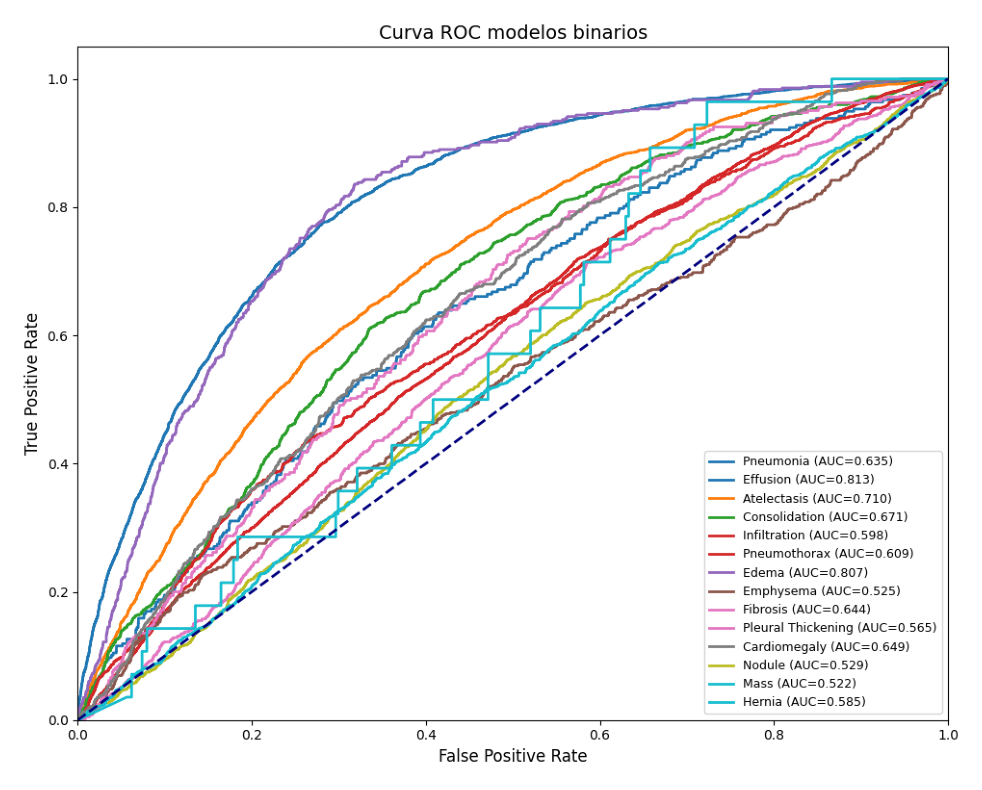

In [10]:
roc_path = root / 'results' / 'roc' / 'pregunta3_roc_all.png'
if roc_path.exists():
    img = mpimg.imread(str(roc_path))
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Ejecutar plot_roc.py para generar pregunta3_roc_all.png')

**Figura 1.** Curvas ROC para las 14 enfermedades, ordenadas por AUC en la leyenda. Effusion (AUC=0.813) y Edema (AUC=0.807) se destacan notablemente del resto, con curvas que se elevan rápidamente hacia la esquina superior izquierda. En el otro extremo, Mass (AUC=0.522) y Emphysema (AUC=0.525) siguen de cerca a la diagonal, indicando que el modelo no logra distinguir entre clases positivas y negativas para esas patologías con los recursos actuales.

## Matrices de Confusión

Cada matriz de confusión enfrenta las predicciones del modelo (eje horizontal) contra los valores reales (eje vertical). La diagonal principal (TN y TP) representa los aciertos. Una matriz ideal tiene valores altos en la diagonal y cero fuera de ella. Estas matrices se generaron con un umbral de decisión de 0.5.

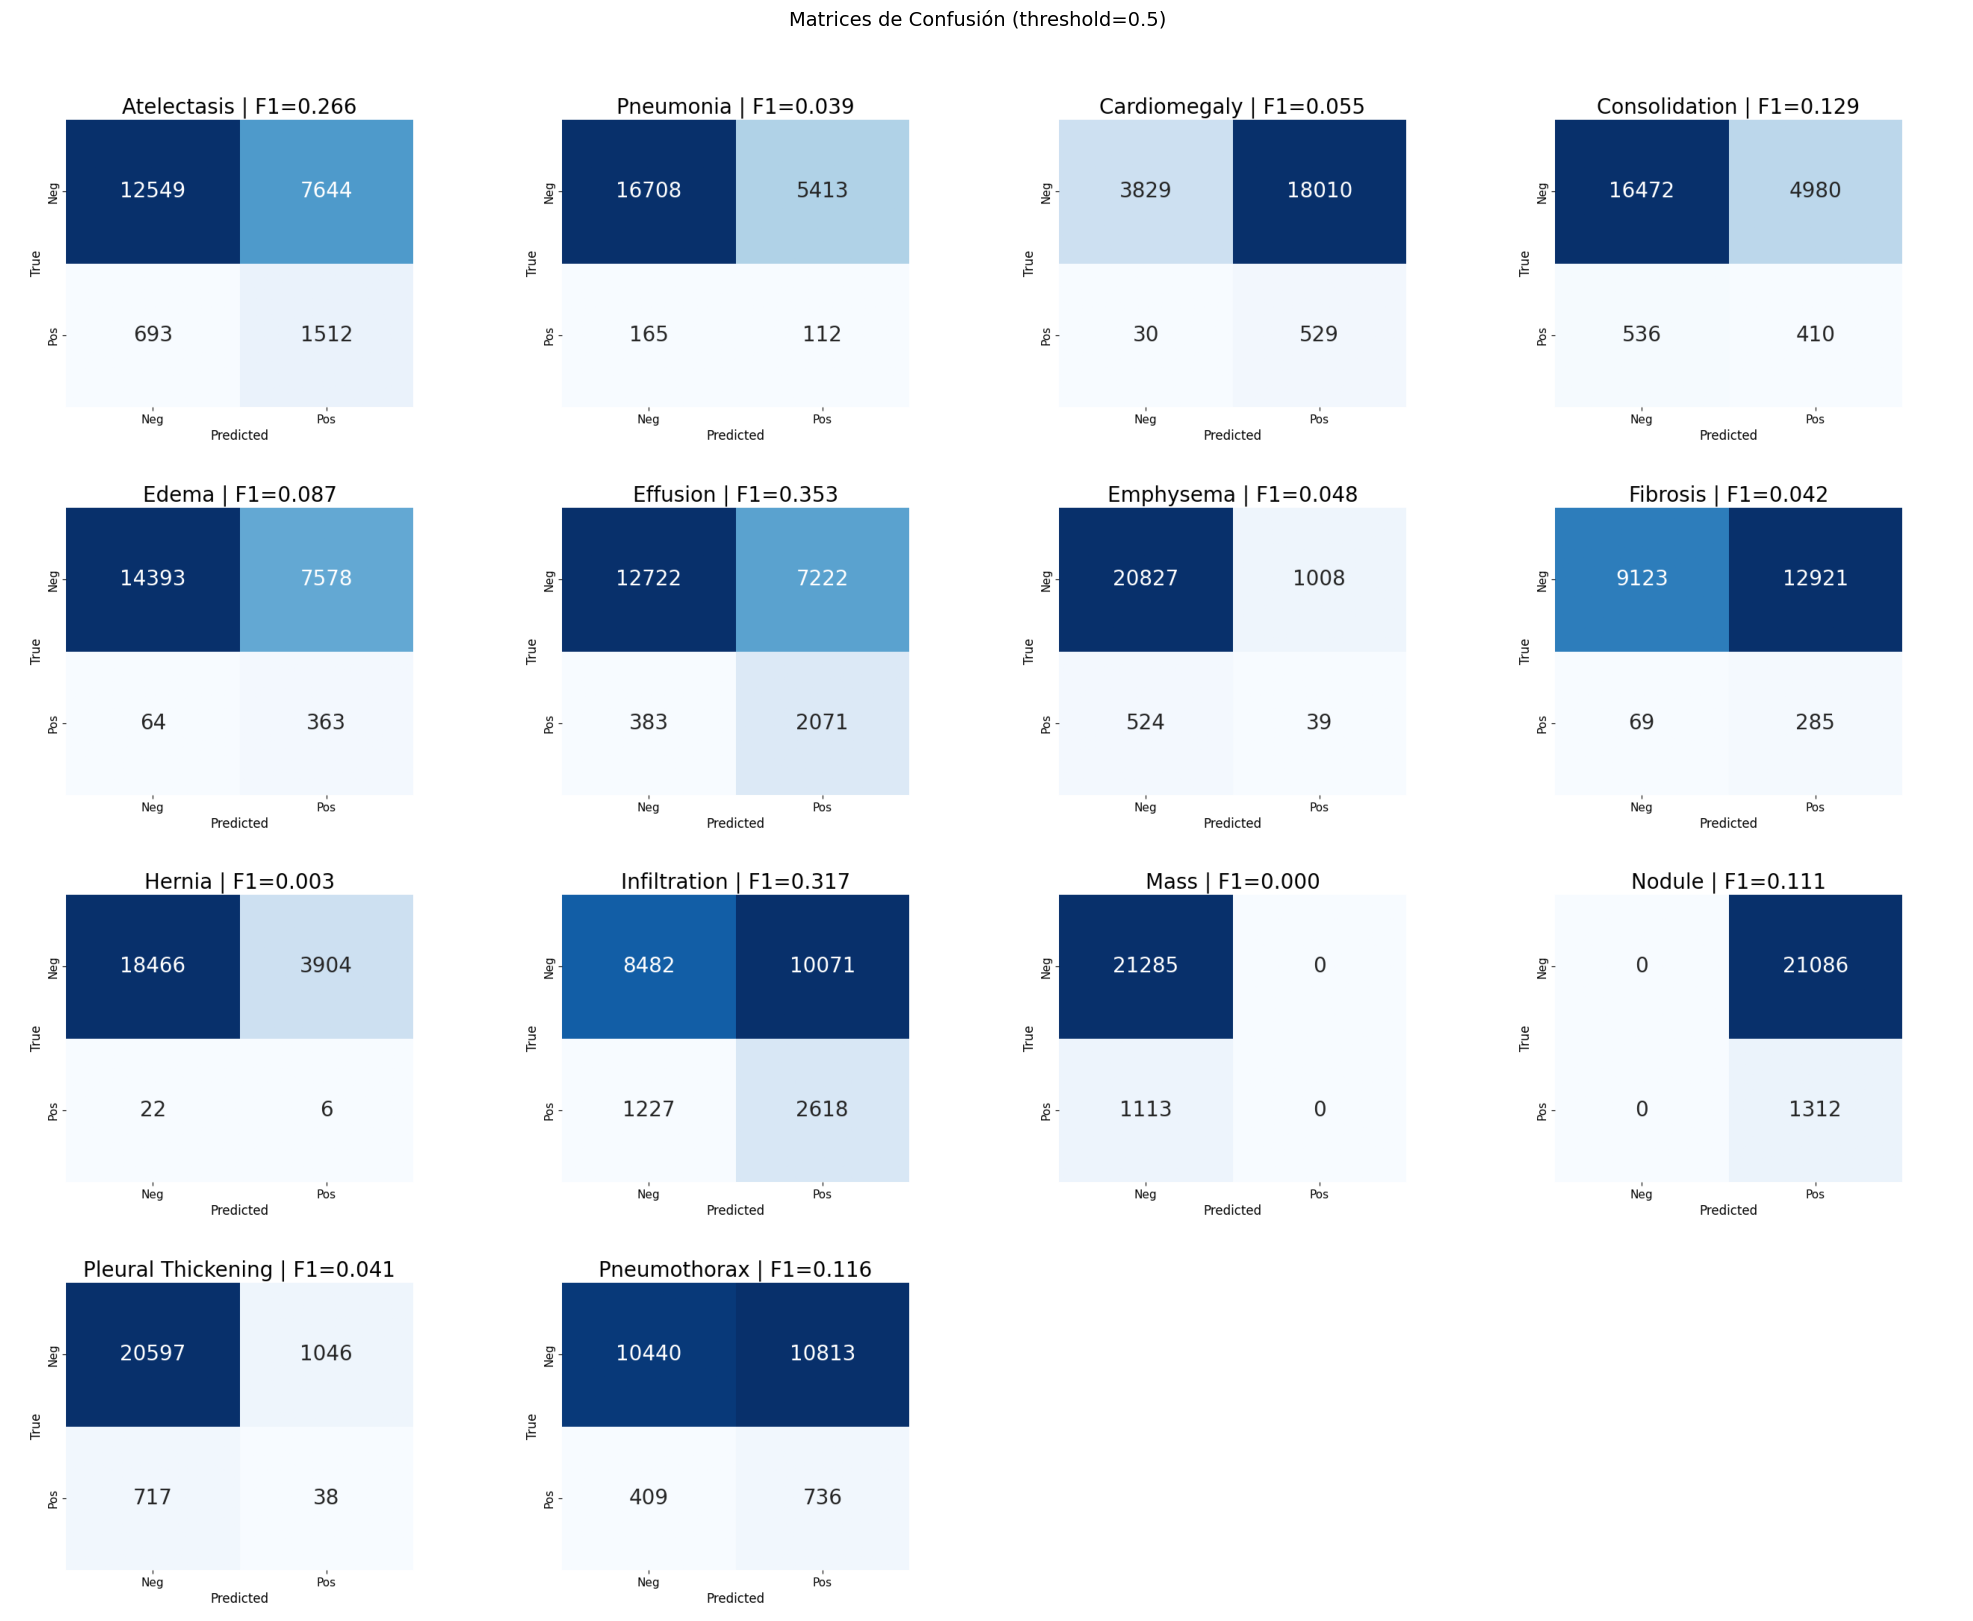

In [4]:
CONF_DIR = root / 'results' / 'confusion'
conf_pngs = sorted([f for f in os.listdir(CONF_DIR) if f.endswith('.png') and f != 'example.png'])

n = len(conf_pngs)
ncols, nrows = 4, int(np.ceil(n / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()
for i, fname in enumerate(conf_pngs):
    axes[i].imshow(mpimg.imread(str(CONF_DIR / fname)))
    axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Matrices de Confusión (threshold=0.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Figura 2.** Matrices de confusión para las 14 enfermedades. Cada matriz incluye el F1-Score en el título. Se observan dos problemas recurrentes: primero, varias enfermedades muestran un claro sesgo hacia la clase negativa (muchos TN y FN pero pocos TP), como en Cardiomegaly, Fibrosis y Hernia, donde el modelo prácticamente siempre predice "ausente". Segundo, dos casos extremos de colapso: Mass predice todo como negativo (TP=0) y Nodule predice todo como positivo (TN=0), lo que indica que el entrenamiento con una sola época no fue suficiente para que estos modelos aprendieran un comportamiento útil. Effusion es el caso más equilibrado, con 2071 TP frente a 383 FN.

## Comparación de Métricas

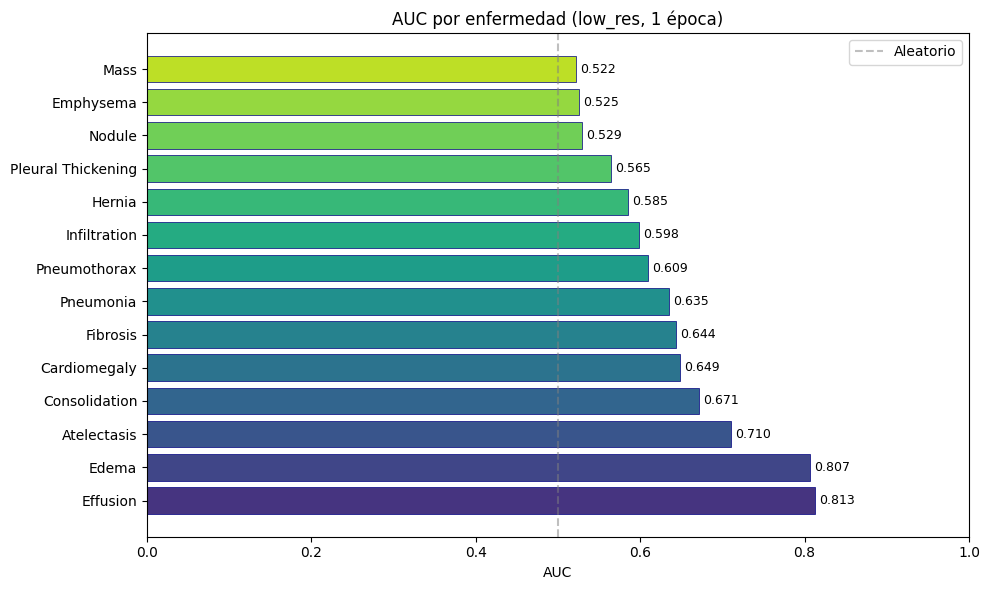

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(df)))
bars = ax.barh(range(len(df)), df['AUC'].values, color=colors, edgecolor='navy', linewidth=0.5)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Enfermedad'].values)
ax.set_xlabel('AUC')
ax.set_xlim(0, 1)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatorio')
ax.set_title('AUC por enfermedad (low_res, 1 época)')
for bar, auc in zip(bars, df['AUC'].values):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{auc:.3f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

**Figura 3.** AUC por enfermedad en orden descendente. La línea punteada marca el rendimiento aleatorio (0.50). Effusion (0.813), Edema (0.807) y Atelectasis (0.710) son las únicas enfermedades que superan 0.70, lo que sugiere que estas patologías presentan patrones radiográficos más distintivos y aprendibles incluso con resolución reducida y entrenamiento mínimo. Las enfermedades con AUC por debajo de 0.60 no lograron un aprendizaje significativo; en particular Mass (0.522), Emphysema (0.525) y Nodule (0.529) se comportan esencialmente como clasificadores aleatorios.

## Mapas de Activación (CAM)

Se muestran tres ejemplos de Verdaderos Positivos del modelo de Effusion (AUC=0.813), el de mejor rendimiento entre las enfermedades. La imagen izquierda de cada par es la radiografía original y la derecha el mapa CAM superpuesto.

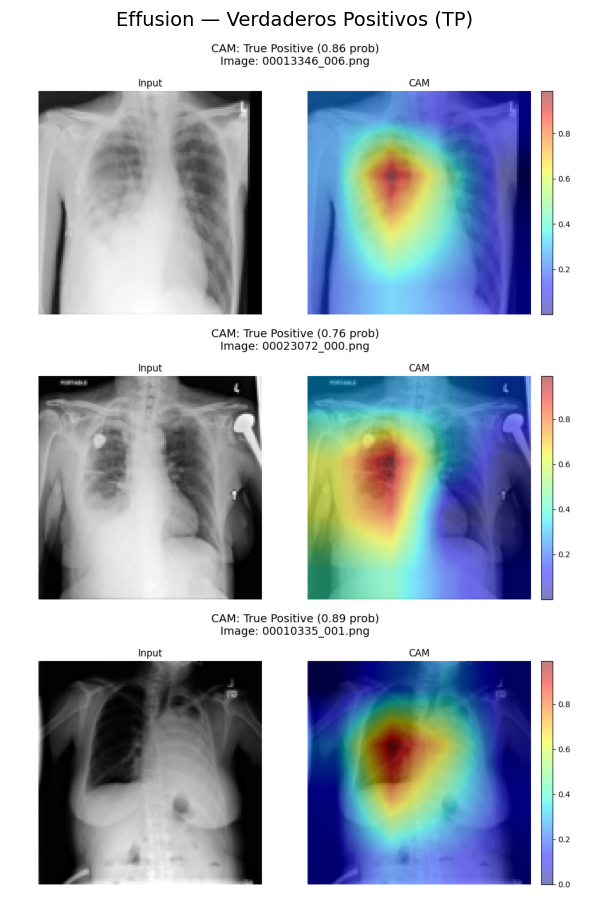

In [6]:
cam_path = root / 'results' / 'cam' / 'effusion_tp_combined.png'
if cam_path.exists():
    img = mpimg.imread(str(cam_path))
    fig, ax = plt.subplots(figsize=(6, 12))
    ax.imshow(img)
    ax.set_title('Effusion — Verdaderos Positivos (TP)', fontsize=14, pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No se encuentra effusion_tp_combined.png')

**Figura 4.** Cada fila muestra un caso de derrame pleural (Effusion) correctamente clasificado. La imagen izquierda de cada par es la radiografía original y la derecha el mapa CAM superpuesto, donde las zonas en rojo y amarillo indican las regiones que más contribuyeron a la decisión del modelo.

En los dos primeros ejemplos se observa que la activación se concentra en el pulmón que aparece más blanco y opaco en la radiografía, que es precisamente el que presenta el derrame pleural. El modelo está aprendiendo a detectar la opacidad característica que el líquido produce en el espacio pleural. En el tercer ejemplo, en cambio, la activación se desplaza hacia el pulmón de aspecto más oscuro, que aparentemente es el sano. Esto podría indicar que el modelo está utilizando una estrategia de comparación entre ambos pulmones: al detectar que uno está opaco (anormal) y el otro no, se fija en el sano como referencia para confirmar la anomalía del lado opuesto.

## Conclusión

Sí es posible entrenar un modelo que prediga correctamente algunas enfermedades pulmonares a partir de radiografías de tórax, aunque con limitaciones importantes. Effusion (AUC=0.813), Edema (AUC=0.807) y Atelectasis (AUC=0.710) alcanzaron un rendimiento moderadamente bueno incluso con condiciones adversas: resolución de 128×128, una sola época de entrenamiento y un umbral fijo de 0.5. Estos resultados sugieren que estas enfermedades tienen patrones radiológicos lo suficientemente distintivos como para ser capturados por una DenseNet-121 incluso con recursos computacionales mínimos.

Sin embargo, la mayoría de las enfermedades evaluadas presentaron AUC cercanos al azar o directamente colapsaron (Mass predecía siempre negativo, Nodule siempre positivo). Esto se debe principalmente al desbalance extremo de clases combinado con un entrenamiento insuficiente. Con solo una época, el modelo no alcanza a converger, y la resolución de 128×128 probablemente sea insuficiente para detectar patrones finos como nódulos pequeños o fibrosis temprana. Se espera que con resolución completa (224×224), más épocas y ajuste de umbral por enfermedad, varias de las patologías con rendimiento actualmente bajo podrían alcanzar niveles clínicamente útiles.